# K-means Clustering Algorithm
Clustering is a technique to find groups of objects that have high similarity.
K-means uses the following concepts:

The centroid of a cluster is the arithmetic mean of all points belonging to that cluster.

Each point is closer to the centroid of its own cluster than to the centroids of other clusters (measured by similarity distance).

In [1]:
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=150,
    n_features=2,
    centers=3,
    cluster_std=0.5,
    shuffle=True,
    random_state=0,
)

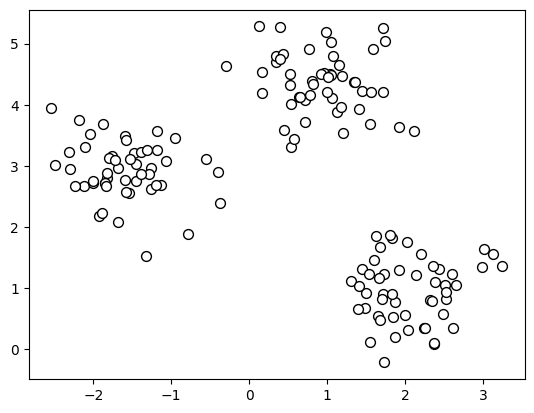

In [3]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c="white", marker="o", edgecolor="black", s=50)
plt.show()

In [6]:
from sklearn.cluster import KMeans

km = KMeans(
    n_clusters=3, init="random", n_init=10, max_iter=300, tol=1e-04, random_state=0
)
km.fit(X)
y_km = km.predict(X)  # y pred
y_km

array([2, 1, 1, 1, 2, 1, 1, 2, 0, 1, 2, 0, 0, 1, 1, 0, 0, 2, 0, 2, 1, 2,
       1, 1, 0, 2, 2, 1, 0, 2, 0, 0, 0, 0, 1, 2, 2, 2, 1, 1, 0, 0, 1, 2,
       2, 2, 0, 1, 0, 1, 2, 1, 1, 2, 2, 0, 1, 2, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 2, 1, 1, 1, 2, 2, 1, 2, 1, 1, 0, 0, 1, 2, 2, 1, 1, 2, 2, 2, 0,
       0, 2, 2, 1, 2, 1, 2, 1, 0, 0, 2, 2, 2, 2, 0, 2, 2, 1, 0, 1, 1, 1,
       0, 1, 2, 0, 1, 0, 1, 1, 0, 0, 1, 2, 1, 1, 2, 2, 0, 2, 0, 0, 0, 0,
       2, 0, 0, 0, 1, 0, 2, 0, 1, 1, 2, 2, 0, 0, 0, 0, 2, 2], dtype=int32)

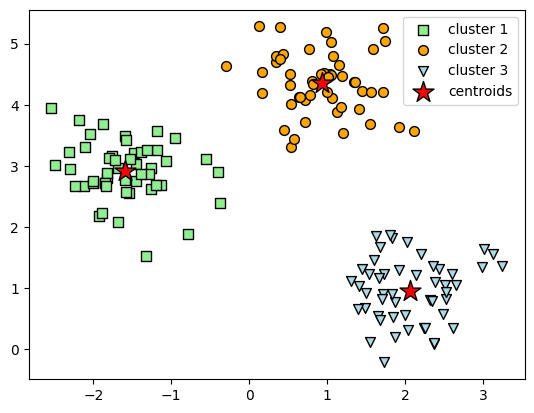

In [7]:
plt.scatter(
    X[y_km == 0, 0],
    X[y_km == 0, 1],
    s=50,
    c="lightgreen",
    marker="s",
    edgecolor="black",
    label="cluster 1",
)
plt.scatter(
    X[y_km == 1, 0],
    X[y_km == 1, 1],
    s=50,
    c="orange",
    marker="o",
    edgecolor="black",
    label="cluster 2",
)
plt.scatter(
    X[y_km == 2, 0],
    X[y_km == 2, 1],
    s=50,
    c="lightblue",
    marker="v",
    edgecolor="black",
    label="cluster 3",
)
plt.scatter(
    km.cluster_centers_[:, 0],
    km.cluster_centers_[:, 1],
    s=250,
    marker="*",
    c="red",
    edgecolor="black",
    label="centroids",
)
plt.legend(scatterpoints=1)

plt.show()

# Determining the Optimal Number of Clusters

Before performing K-Means, you need to explicitly specify the number of clusters. But how can you decide the best number of clusters?

You can use the Inertia value to help select the optimal number of clusters. The inertia value is the sum of squared distances between each data point and its cluster centroid after clustering, which indicates the cohesion of clusters. The smaller the inertia, the better the cohesion, meaning the clusters are well-formed.

Below is a code example that runs clustering on the data with cluster numbers from 1 to 6 and prints the inertia value for each cluster count.

Text(0, 0.5, 'inertia')

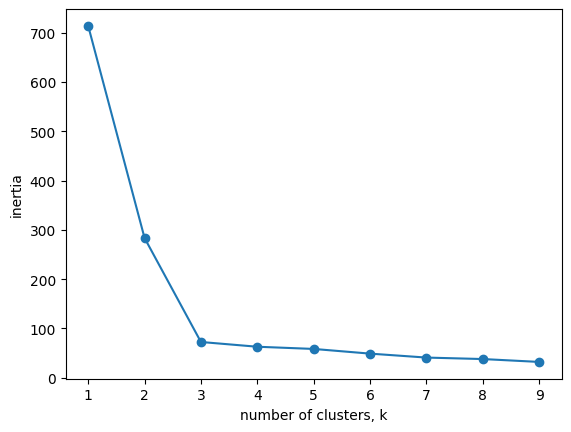

In [8]:
ks = range(1, 10)
inertias = []

for k in ks:
    model = KMeans(n_clusters=k)
    model.fit(X)
    inertias.append(model.inertia_)

# Plot ks vs inertias
plt.plot(ks, inertias, "-o")
plt.xlabel("number of clusters, k")
plt.ylabel("inertia")

# Iris Example